In [2]:
import jax.numpy as jnp 
import jax
import matplotlib.pyplot as plt 
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation
import diffrax
import equinox

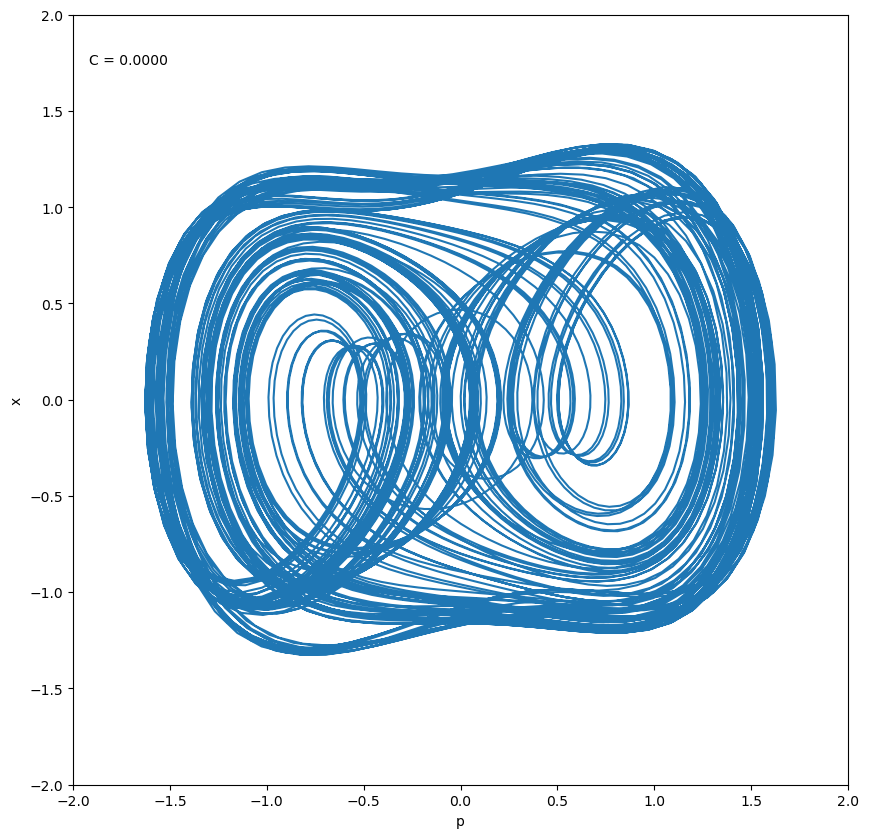

In [13]:
# Constants (fixed)
C = 0.0
k = 0.575
omega = 1.2
gamma = 1.0
alpha = 1.0
beta = -1.0

varToTest = "C"
values = jnp.linspace(0.0, 0.99, 100)

def dx_dt(t, x, params):
    C = params["C"]
    k = params["k"]
    omega = params["omega"]
    gamma = params["gamma"]
    alpha = params["alpha"]
    beta = params["beta"]

    return jnp.array([
        x[1],
        -beta*x[0]
        - k*x[1]
        - alpha*x[0]**3
        + gamma*jnp.cos(omega*t)
        + C
    ])

term = diffrax.ODETerm(dx_dt)
solver = diffrax.Tsit5()
y0 = jnp.array([0.0, 1.0])
ts = jnp.linspace(0, 1000, 10000)

def solve_single(value):
    params = {"C":C,"k":k,"omega":omega,"gamma":gamma,"alpha":alpha,"beta":beta}
    params[varToTest] = value  # dynamically choose which parameter to sweep

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=0,
        t1=5000,
        dt0=0.05,
        y0=y0,
        args=params,
        saveat=diffrax.SaveAt(ts=ts),
        max_steps=1_000_000,
    )
    return sol.ys

# Vectorize over C
batched_solve = jax.vmap(solve_single)

solutions = batched_solve(values)[:,1000:,]

fig, ax = plt.subplots(figsize=(10,10))
line, = ax.plot([], [])
param_text = ax.text(
    0.02, 0.95, "", 
    transform=ax.transAxes,
    verticalalignment='top'
)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
ax.set_ylabel('x')
ax.set_xlabel('p')

def update(frame):
    current_value = values[frame]

    line.set_data(
        solutions[frame, :, 0],
        solutions[frame, :, 1]
    )

    param_text.set_text(f"{varToTest} = {float(current_value):.4f}")

    return line, param_text

ani = animation.FuncAnimation(
    fig, update, frames=100, interval=50
)
ani.save("duffing_animationVarC2.mp4", writer="ffmpeg", fps=10)